In [349]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q= 0.85)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

In [350]:
df_countries.loc[
    df_countries["fossil_fuel_energy_consumption_of_total"] < 0,
    "fossil_fuel_energy_consumption_of_total"
] = np.nan

df_countries.loc[
    df_countries["gross_capital_formation_of_gdp"] < 0,
    "gross_capital_formation_of_gdp"
] = np.nan

In [351]:
df_countries.drop(columns=['exports_of_goods_and_services_of_gdp', 'imports_of_goods_and_services_of_gdp'], inplace=True)

In [352]:
df_countries['trade_of_gdp_log'] = np.log1p(df_countries['trade_of_gdp'])
df_countries.drop(columns=['trade_of_gdp'], inplace=True)

In [353]:
index_components = [
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
]

internet_col = "individuals_using_the_internet_of_population"

# 1. Country-level mean
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("country_code")[internet_col]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("year")[internet_col]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(df_countries[internet_col].mean())
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_countries[
    [f"{col}_z" for col in index_components]
] = scaler.fit_transform(
    df_countries[index_components]
)

df_countries["Socioeconomic_developmen_Index"] = (
    df_countries[[f"{col}_z" for col in index_components]]
    .mean(axis=1)
)

In [354]:
df_countries.drop(columns=[
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population",
    'individuals_using_the_internet_of_population_z',
    'life_expectancy_at_birth_total_years_z',
    'urban_population_of_total_population_z',
    'access_to_electricity_of_population_z'
], inplace=True)

In [355]:
energy_cols = [
    "energy_use_kg_of_oil_equivalent_per_capita",
    "carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita"
]


# 1. Country-level mean
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("country_code")[energy_cols]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("year")[energy_cols]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(df_countries[energy_cols].mean())
)


# 4. LOG TRANSFORMATION

df_log = np.log1p(df_countries[energy_cols])


# 5. STANDARDIZATION
scaler = StandardScaler()
z_cols = [f"{col}_z" for col in energy_cols]
df_countries[z_cols] = scaler.fit_transform(df_log)


# 6. CREATE ENERGY & ENVIRONMENTAL INDEX
df_countries["Energy_Environmental_Index"] = (
    df_countries[z_cols].mean(axis=1)
)


# 7. DROP ORIGINAL COMPONENTS
df_countries.drop(columns=energy_cols, inplace=True)
df_countries.drop(columns=['energy_use_kg_of_oil_equivalent_per_capita_z', 'carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita_z'], inplace=True)

In [356]:
df_countries['domestic_credit_to_private_sector_of_gdp_log'] = np.log1p(df_countries['domestic_credit_to_private_sector_of_gdp'])
df_countries.drop(columns= 'domestic_credit_to_private_sector_of_gdp', inplace=True)

In [357]:
fdi = df_countries['foreign_direct_investment_net_inflows_of_gdp']

df_countries['fdi_log'] = np.sign(fdi) * np.log1p(np.abs(fdi))
df_countries.drop(columns='foreign_direct_investment_net_inflows_of_gdp', inplace=True)

In [358]:
inflation = df_countries['inflation_consumer_prices_annual_']

df_countries['inflation_log'] = (np.sign(inflation)* np.log1p(np.abs(inflation)))
df_countries.drop(columns='inflation_consumer_prices_annual_', inplace=True)

In [359]:
df_countries['broad_money_of_gdp_log'] = np.log1p(df_countries['broad_money_of_gdp'])
df_countries.drop(columns='broad_money_of_gdp', inplace=True)

In [360]:
df_countries['gdp_per_capita_constant_2015_us_log'] = np.log1p(df_countries['gdp_per_capita_constant_2015_us'])
df_countries.drop(columns='gdp_per_capita_constant_2015_us', inplace=True)

In [361]:
df_countries['military_expenditure_of_general_government_expenditure_log'] = np.log1p(df_countries['military_expenditure_of_general_government_expenditure'])
df_countries.drop(columns='military_expenditure_of_general_government_expenditure', inplace=True)

### The model 

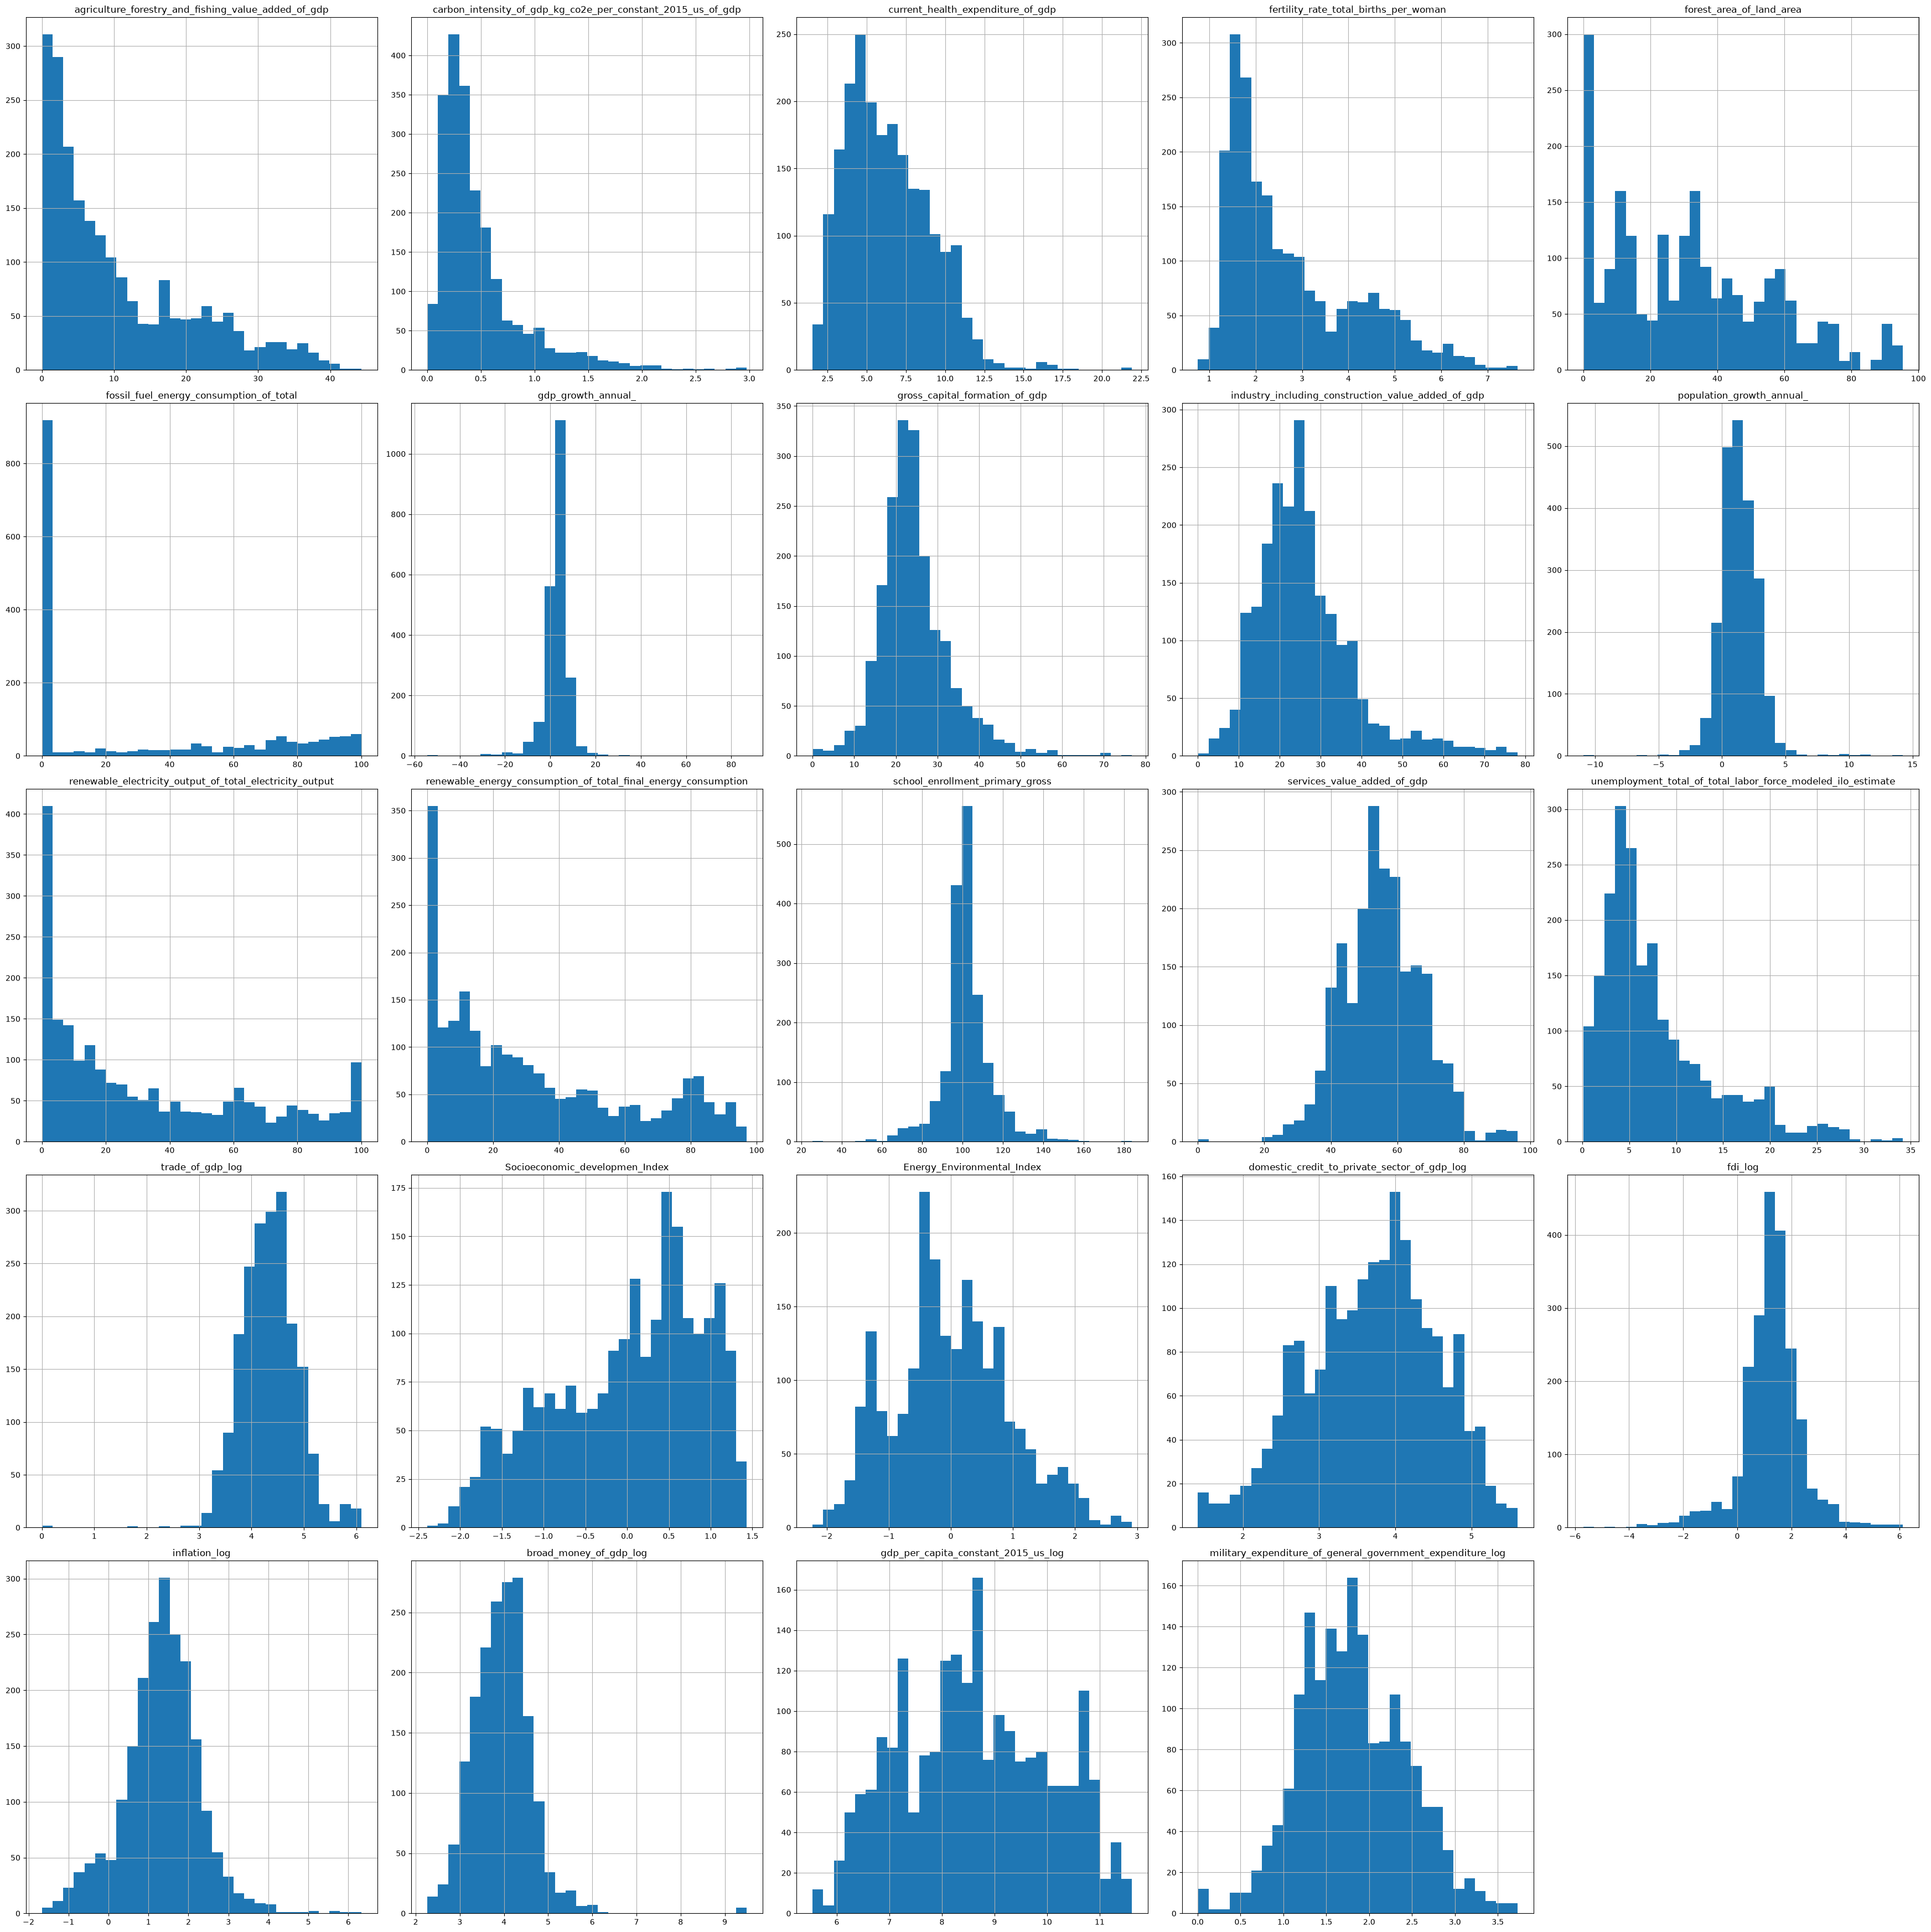

In [362]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].hist(
    figsize=(35, 35),
    bins=30
)

plt.tight_layout()
plt.show()

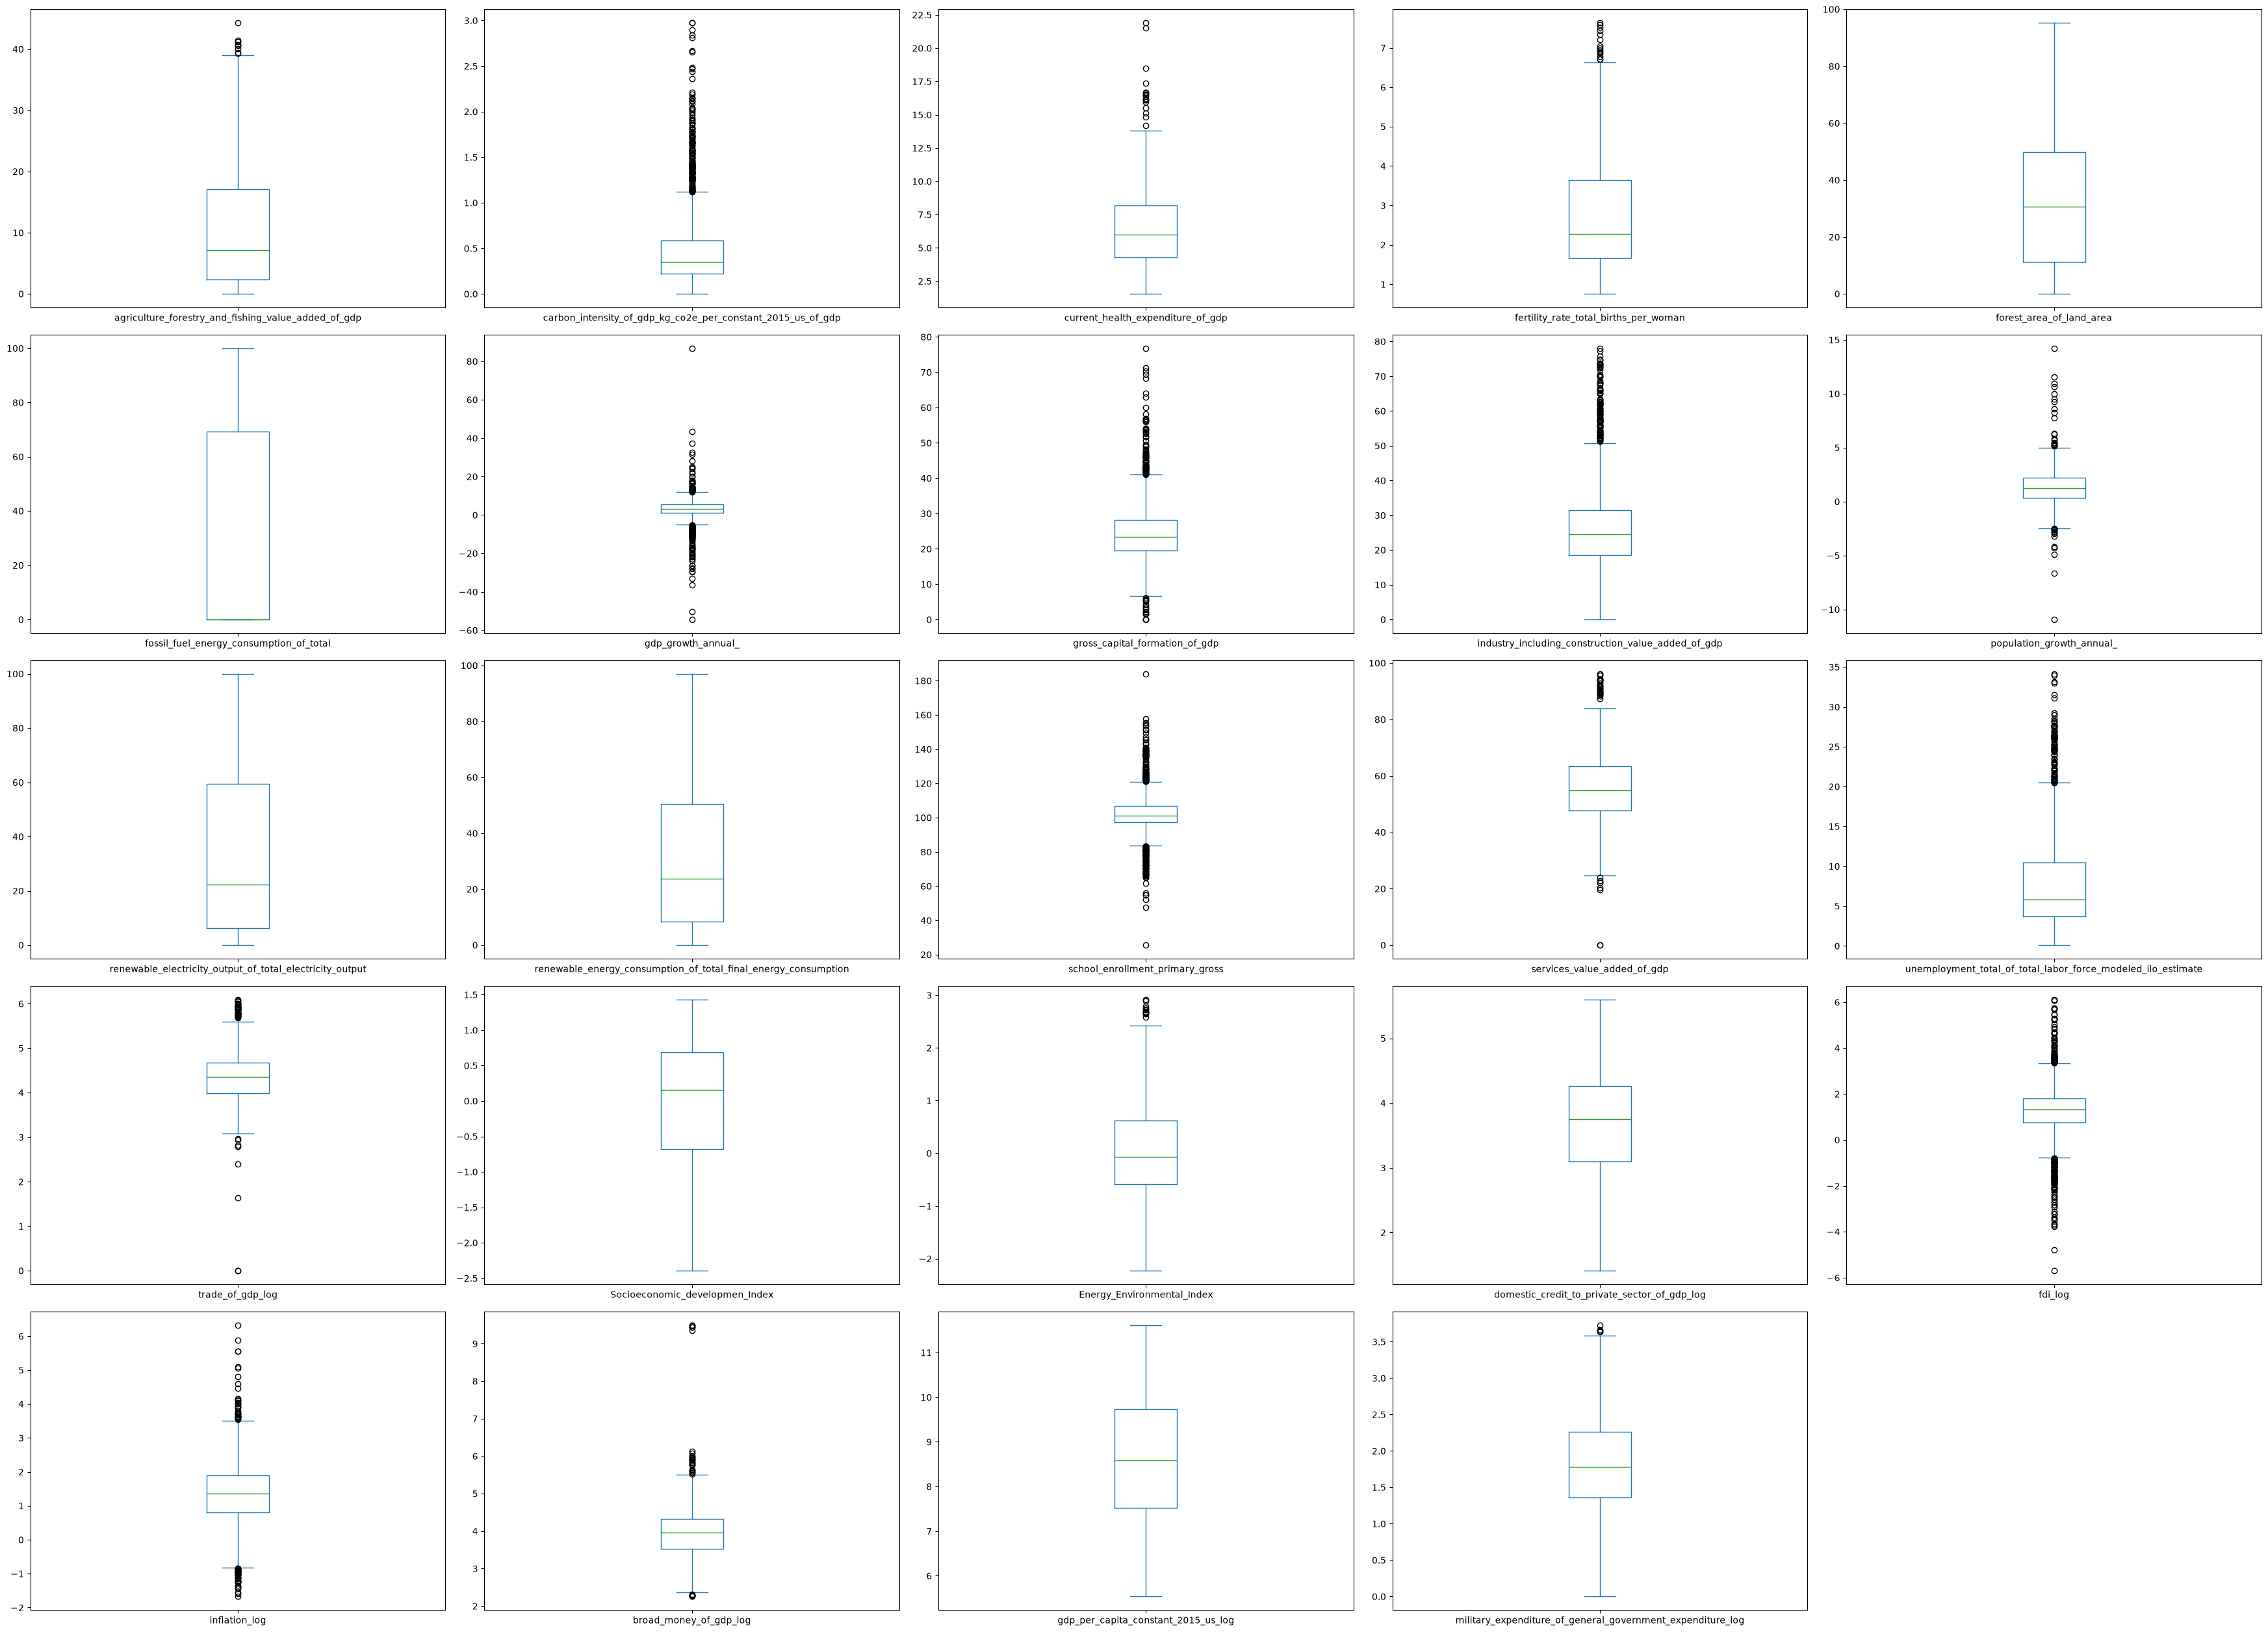

In [363]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(7, 5),
    figsize=(35, 35),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

In [364]:
df_countries.shape

(2184, 27)

In [365]:
# Select only years 2010–2021
df_2010_2021 = df_countries[
    df_countries["year"].between(2010, 2021)
].copy()

indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Number of years
n_years = df_2010_2021["year"].nunique()

# Number of countries
n_countries = df_2010_2021["country_name"].nunique()

summary = []

for col in indicator_cols:

    # Number of missing values for each country
    country_nulls = (
        df_2010_2021
        .groupby("country_name")[col]
        .apply(lambda x: x.isna().sum())
    )

    # Countries where ALL 12 years are NULL
    totally_null_countries = country_nulls[
        country_nulls == n_years
    ]

    # Countries where SOME but NOT ALL years are NULL
    partially_null_countries = country_nulls[
        (country_nulls > 0) & (country_nulls < n_years)
    ]

    # Total NULL cells
    total_nulls = country_nulls.sum()

    # NULL cells from completely-null countries
    total_nulls_totally_null = totally_null_countries.sum()

    # NULL cells from partially-null countries
    total_nulls_partially_null = partially_null_countries.sum()

    summary.append({
        "indicator": col,
        "totally_null_countries_number":
            len(totally_null_countries),
        "total_nulls_from_totally_null_countries":
            total_nulls_totally_null,
        "partially_null_countries_number":
            len(partially_null_countries),
        "total_nulls_from_partially_null_countries":
            total_nulls_partially_null,
        "total_null_values":
            total_nulls
    })


# Convert list → DataFrame
summary = pd.DataFrame(summary)


# Percentage of NULL values
summary["null_percentage"] = (
    summary["total_null_values"]
    / (n_countries * n_years)
    * 100
)


# Reorder columns
summary = summary[
    [
        "null_percentage",
        "indicator",
        "totally_null_countries_number",
        "total_nulls_from_totally_null_countries",
        "partially_null_countries_number",
        "total_nulls_from_partially_null_countries",
        "total_null_values"
    ]
]


# Sort by missing percentage
summary = summary.sort_values(
    "null_percentage",
    ascending=False
).reset_index(drop=True)

summary

,null_percentage,indicator,totally_null_countries_number,total_nulls_from_totally_null_countries,partially_null_countries_number,total_nulls_from_partially_null_countries,total_null_values
0,22.985348,fossil_fuel_energy_consumption_of_total,38,456,19,46,502
1,19.871795,military_expenditure_of_general_government_exp...,28,336,21,98,434
2,18.452381,broad_money_of_gdp_log,26,312,25,91,403
3,15.293040,school_enrollment_primary_gross,3,36,81,298,334
4,10.714286,gross_capital_formation_of_gdp,15,180,9,54,234
5,9.157509,trade_of_gdp_log,12,144,11,56,200
6,8.699634,domestic_credit_to_private_sector_of_gdp_log,5,60,34,130,190
7,3.067766,inflation_log,2,24,12,43,67
8,3.067766,renewable_electricity_output_of_total_electric...,1,12,13,55,67
9,2.747253,unemployment_total_of_total_labor_force_modele...,5,60,0,0,60


In [366]:
# Select only years 2010–2021
df_2010_2021 = df_countries[
    df_countries["year"].between(2010, 2021)
].copy()

indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

n_years = df_2010_2021["year"].nunique()
n_countries = df_2010_2021["country_name"].nunique()

# 1. Calculate total null count per country for each indicator
# Resulting shape: (n_countries, n_indicators)
country_nulls = df_2010_2021.groupby("country_name")[indicator_cols].apply(lambda x: x.isna().sum())

summary_rows = []

for col in indicator_cols:
    null_counts = country_nulls[col]
    
    # Base indicators tracking
    totally_null = (null_counts == n_years).sum()
    total_nulls_totally_null = totally_null * n_years
    
    partially_null = ((null_counts > 0) & (null_counts < n_years)).sum()
    total_nulls_partially_null = null_counts[null_counts < n_years].sum()
    
    total_nulls = null_counts.sum()
    
    row_dict = {
        "null_percentage": (total_nulls / (n_countries * n_years)) * 100,
        "indicator": col,
        "total_null_values": total_nulls
    }
    
    # 2. Add dynamic breakdown columns for countries missing 1, 2, ..., n_years
    for k in range(1, n_years + 1):
        countries_with_k_nulls = (null_counts == k).sum()
        row_dict[f"countries_with_{k}_nulls"] = countries_with_k_nulls
        row_dict[f"nulls_from_{k}_null_countries"] = countries_with_k_nulls * k
        
    summary_rows.append(row_dict)

# Convert to DataFrame
summary = pd.DataFrame(summary_rows)

# Sort by missing percentage
summary = summary.sort_values("null_percentage", ascending=False).reset_index(drop=True)

summary

,null_percentage,indicator,total_null_values,countries_with_1_nulls,nulls_from_1_null_countries,countries_with_2_nulls,nulls_from_2_null_countries,countries_with_3_nulls,nulls_from_3_null_countries,countries_with_4_nulls,...,countries_with_8_nulls,nulls_from_8_null_countries,countries_with_9_nulls,nulls_from_9_null_countries,countries_with_10_nulls,nulls_from_10_null_countries,countries_with_11_nulls,nulls_from_11_null_countries,countries_with_12_nulls,nulls_from_12_null_countries
0,22.985348,fossil_fuel_energy_consumption_of_total,502,8,8,3,6,4,12,0,...,0,0,0,0,0,0,0,0,38,456
1,19.871795,military_expenditure_of_general_government_exp...,434,3,3,5,10,3,9,2,...,1,8,1,9,1,10,2,22,28,336
2,18.452381,broad_money_of_gdp_log,403,6,6,7,14,2,6,3,...,2,16,0,0,1,10,1,11,26,312
3,15.293040,school_enrollment_primary_gross,334,22,22,20,40,8,24,6,...,5,40,1,9,1,10,4,44,3,36
4,10.714286,gross_capital_formation_of_gdp,234,0,0,0,0,2,6,1,...,0,0,0,0,1,10,1,11,15,180
5,9.157509,trade_of_gdp_log,200,1,1,0,0,3,9,2,...,0,0,0,0,1,10,1,11,12,144
6,8.699634,domestic_credit_to_private_sector_of_gdp_log,190,7,7,9,18,1,3,3,...,2,16,0,0,1,10,1,11,5,60
7,3.067766,inflation_log,67,1,1,6,12,0,0,0,...,1,8,0,0,0,0,0,0,2,24
8,3.067766,renewable_electricity_output_of_total_electric...,67,2,2,3,6,2,6,1,...,0,0,0,0,1,10,1,11,1,12
9,2.747253,unemployment_total_of_total_labor_force_modele...,60,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,60


In [367]:
# Years to analyze
years = list(range(2010, 2022))

# Indicator columns
indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Keep only 2010–2021
df_10_21 = df_countries[
    df_countries["year"].isin(years)
].copy()

# Check whether each indicator is completely NULL
# for each country across all 12 years
fully_null_by_country = (
    df_10_21
    .groupby(["country_name", "country_code"])[indicator_cols]
    .apply(lambda x: x.isna().all())
)

# Get the actual indicator names that are completely NULL
country_null_summary = (
    fully_null_by_country
    .apply(lambda row: row[row].index.tolist(), axis=1)
    .reset_index(name="fully_null_indicators")
)

# Count them
country_null_summary["fully_null_count"] = (
    country_null_summary["fully_null_indicators"].str.len()
)

# Percentage
country_null_summary["fully_null_percentage"] = (
    country_null_summary["fully_null_count"]
    / len(indicator_cols)
    * 100
)

# Sort from most missing to least missing
country_null_summary = country_null_summary.sort_values(
    "fully_null_count",
    ascending=False
).reset_index(drop=True)

country_null_summary

,country_name,country_code,fully_null_indicators,fully_null_count,fully_null_percentage
0,"Macao SAR, China",MAC,[agriculture_forestry_and_fishing_value_added_...,6,25.000000
1,Cuba,CUB,"[domestic_credit_to_private_sector_of_gdp_log,...",5,20.833333
2,Kiribati,KIR,"[fossil_fuel_energy_consumption_of_total, unem...",5,20.833333
3,Turkmenistan,TKM,"[gross_capital_formation_of_gdp, domestic_cred...",5,20.833333
4,Barbados,BRB,"[fossil_fuel_energy_consumption_of_total, gros...",4,16.666667
...,...,...,...,...,...
177,Uzbekistan,UZB,[],0,0.000000
178,Viet Nam,VNM,[],0,0.000000
179,"Yemen, Rep.",YEM,[],0,0.000000
180,Zambia,ZMB,[],0,0.000000


In [368]:
for _, row in summary.iterrows():
    print(f"\n{row['indicator']}")
    print("-" * 80)
    
    for k in range(1, n_years + 1):
        count = row[f"countries_with_{k}_nulls"]
        
        if count > 0:
            print(f"{k:2} missing years : {'█' * count} ({count} countries)")


fossil_fuel_energy_consumption_of_total
--------------------------------------------------------------------------------
 1 missing years : ████████ (8 countries)
 2 missing years : ███ (3 countries)
 3 missing years : ████ (4 countries)
 5 missing years : ████ (4 countries)
12 missing years : ██████████████████████████████████████ (38 countries)

military_expenditure_of_general_government_expenditure_log
--------------------------------------------------------------------------------
 1 missing years : ███ (3 countries)
 2 missing years : █████ (5 countries)
 3 missing years : ███ (3 countries)
 4 missing years : ██ (2 countries)
 5 missing years : █ (1 countries)
 7 missing years : ██ (2 countries)
 8 missing years : █ (1 countries)
 9 missing years : █ (1 countries)
10 missing years : █ (1 countries)
11 missing years : ██ (2 countries)
12 missing years : ████████████████████████████ (28 countries)

broad_money_of_gdp_log
-------------------------------------------------------------

In [369]:
indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Count total missing values per year
nulls_per_year = (
    df_countries
    .groupby(["year"])[indicator_cols]
    .apply(lambda x: x.isna().sum().sum())
)

nulls_per_year

year
2010    238
2011    235
2012    222
2013    222
2014    215
2015    217
2016    204
2017    217
2018    225
2019    234
2020    246
2021    253
dtype: int64

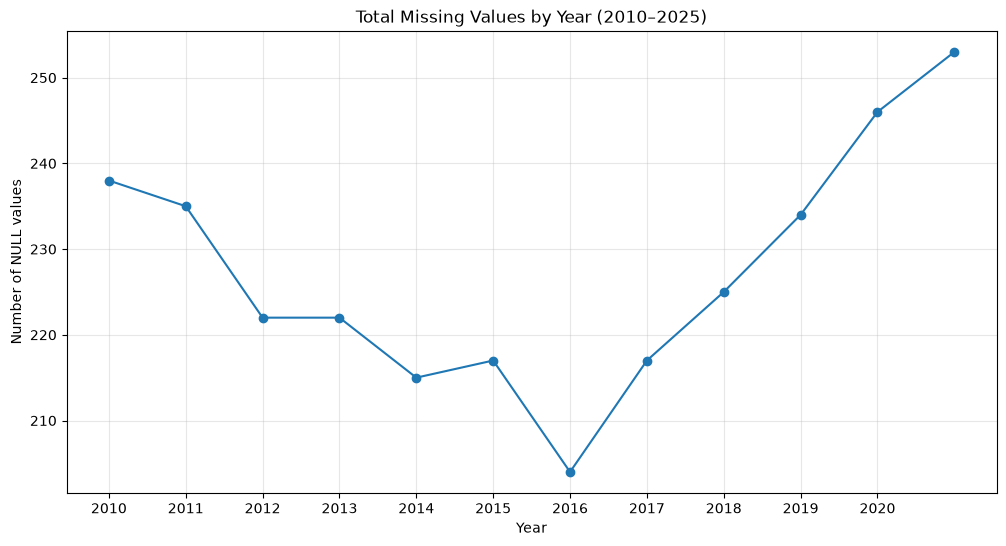

In [370]:
# Indicator columns only
indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Count total missing values per year
nulls_per_year = (
    df_countries
    .groupby(["year"])[indicator_cols]
    .apply(lambda x: x.isna().sum().sum())
)

plt.figure(figsize=(12, 6))

plt.plot(
    nulls_per_year.index,
    nulls_per_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of NULL values")
plt.title("Total Missing Values by Year (2010–2025)")
plt.xticks(range(2010, 2021))
plt.grid(alpha=0.3)

plt.show()

In [371]:
df_countries.sort_values(by=['country_code'])

Series Name,country_name,country_code,year,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,fossil_fuel_energy_consumption_of_total,gdp_growth_annual_,...,unemployment_total_of_total_labor_force_modeled_ilo_estimate,trade_of_gdp_log,Socioeconomic_developmen_Index,Energy_Environmental_Index,domestic_credit_to_private_sector_of_gdp_log,fdi_log,inflation_log,broad_money_of_gdp_log,gdp_per_capita_constant_2015_us_log,military_expenditure_of_general_government_expenditure_log
149,Aruba,ABW,2015,0.012520,0.156097,NaN,1.899,2.333333,NaN,3.611479,...,NaN,4.952250,0.674044,0.408154,4.053989,-0.645670,0.388498,4.286916,10.220457,NaN
155,Aruba,ABW,2021,0.029903,0.179114,NaN,1.631,2.333333,NaN,14.833692,...,NaN,4.945285,0.539899,0.452918,4.240555,1.726696,NaN,4.651521,10.177478,NaN
154,Aruba,ABW,2020,0.021554,0.198103,NaN,1.662,2.333333,NaN,-23.940059,...,NaN,4.822219,0.595208,0.406701,4.424124,2.020836,NaN,4.699579,10.030967,NaN
153,Aruba,ABW,2019,0.018419,0.157090,NaN,1.701,2.333333,NaN,1.229144,...,NaN,4.933922,0.617432,0.452683,4.104833,-1.177794,1.659648,4.347133,10.298948,NaN
152,Aruba,ABW,2018,0.022253,0.145225,NaN,1.732,2.333333,NaN,3.212471,...,NaN,4.940391,0.615853,0.413778,4.042439,1.686365,1.531702,4.325924,10.289437,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3169,Zimbabwe,ZWE,2011,8.666454,0.983843,8.081707,4.126,46.165723,48.302003,14.193916,...,5.368,4.504973,-1.583239,-0.987915,2.994902,1.235555,1.496522,3.076672,7.078286,2.190720
3168,Zimbabwe,ZWE,2010,9.609678,0.713715,10.475753,4.040,46.284813,41.899865,19.675408,...,5.469,4.432285,-1.643813,-1.139412,2.677157,0.701862,1.391946,2.968639,6.963388,1.596103
3178,Zimbabwe,ZWE,2020,20.847051,0.474842,2.954401,3.754,45.093912,0.000000,-7.816951,...,8.617,3.491116,-0.979008,-1.230476,1.535174,0.385596,6.324721,2.398119,7.116247,2.027635
3172,Zimbabwe,ZWE,2014,8.744969,0.642077,8.133513,4.011,45.808453,50.211249,2.376986,...,4.774,4.019473,-1.423496,-1.049064,3.006195,1.230790,-0.180474,3.154954,7.231471,2.124156


In [372]:
# low_missing_cols = [
#     'agriculture_forestry_and_fishing_value_added_of_gdp',
#     'carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp',
#     'current_health_expenditure_of_gdp',
#     'forest_area_of_land_area',
#     'gdp_growth_annual_',
#     'industry_including_construction_value_added_of_gdp',
#     'renewable_electricity_output_of_total_electricity_output',
#     'school_enrollment_primary_gross',
#     'services_value_added_of_gdp',
#     'unemployment_total_of_total_labor_force_modeled_ilo_estimate',
#     'domestic_credit_to_private_sector_of_gdp_log',
#     'fdi_log',
#     'inflation_log',
#     'gdp_per_capita_constant_2015_us_log'
# ]

# df_countries = (
#     df_countries
#     .sort_values(["country_code", "year"])
#     .reset_index(drop=True)
# )

# print("Missing values BEFORE:")
# print(df_countries[low_missing_cols].isna().sum())


# for col in low_missing_cols:

#     # ==================================================
#     # 1. Interpolate small internal gaps within country
#     # ==================================================

#     df_countries[col] = (
#         df_countries
#         .groupby("country_code")[col]
#         .transform(
#             lambda x: x.interpolate(
#                 method="linear",
#                 limit=3,
#                 limit_area="inside"
#             )
#         )
#     )

#     # ==================================================
#     # 2. Calculate each country's typical value
#     # ==================================================

#     country_medians = (
#         df_countries
#         .groupby("country_code")[col]
#         .median()
#     )

#     # ==================================================
#     # 3. Assign countries to deciles
#     # ==================================================

#     country_groups = pd.qcut(
#         country_medians.rank(method="first"),
#         q=10,
#         labels=[f"Decile_{i}" for i in range(1, 11)]
#     )

#     # ==================================================
#     # 4. Calculate median of country medians
#     #    within each decile
#     # ==================================================

#     decile_medians = (
#         country_medians
#         .groupby(country_groups, observed=True)
#         .median()
#     )

#     # ==================================================
#     # 5. Map each country's decile to its rows
#     # ==================================================

#     row_groups = df_countries["country_code"].map(country_groups)

#     # ==================================================
#     # 6. Impute using country's decile median
#     # ==================================================

#     decile_imputation = row_groups.map(decile_medians)

#     df_countries[col] = (
#         df_countries[col]
#         .fillna(decile_imputation)
#     )

#     # ==================================================
#     # 7. If country has no historical data → year median
#     # ==================================================

#     df_countries[col] = (
#         df_countries[col]
#         .fillna(
#             df_countries
#             .groupby("year")[col]
#             .transform("median")
#         )
#     )

#     # ==================================================
#     # 8. Absolute final fallback → global median
#     # ==================================================

#     df_countries[col] = (
#         df_countries[col]
#         .fillna(df_countries[col].median())
#     )


# print("\nMissing values AFTER:")
# print(df_countries[low_missing_cols].isna().sum())

In [373]:
# ==============================================================================
# 1. SETUP FEATURE LISTS
# ==============================================================================

low_missing_cols = [
    "agriculture_forestry_and_fishing_value_added_of_gdp",
    "carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp",
    "current_health_expenditure_of_gdp",
    "forest_area_of_land_area",
    "gdp_growth_annual_",
    "industry_including_construction_value_added_of_gdp",
    "renewable_electricity_output_of_total_electricity_output",
    "school_enrollment_primary_gross",
    "services_value_added_of_gdp",
    "unemployment_total_of_total_labor_force_modeled_ilo_estimate",
    "domestic_credit_to_private_sector_of_gdp_log",
    "fdi_log",
    "inflation_log",
    "gdp_per_capita_constant_2015_us_log",
]

high_missing_cols = [
    "fossil_fuel_energy_consumption_of_total",
    "military_expenditure_of_general_government_expenditure_log",
    "broad_money_of_gdp_log",
    "gross_capital_formation_of_gdp",
    "trade_of_gdp_log",
]

all_cols_to_impute = low_missing_cols + high_missing_cols
anchor_col = "gdp_per_capita_constant_2015_us_log"


# ==============================================================================
# 2. SORT DATA
# ==============================================================================

df_countries = df_countries.sort_values(
    ["country_code", "year"]
).reset_index(drop=True)


# ==============================================================================
# 3. CREATE IMPUTATION METHOD COLUMNS
# ==============================================================================

imputation_method_cols = {}

for col in all_cols_to_impute:
    method_col = f"{col}_imputation_method"
    imputation_method_cols[col] = method_col

    df_countries[method_col] = np.where(
        df_countries[col].isna(), "missing", "observed"
    )


# ==============================================================================
# 4. STRUCTURAL ZERO IMPUTATION
# ==============================================================================

no_military_countries = ["CRI", "ISL", "KIR", "FSM", "MUS", "PAN"]

military_col = "military_expenditure_of_general_government_expenditure_log"
military_method_col = imputation_method_cols[military_col]

mask_structural_zero = (
    df_countries["country_code"].isin(no_military_countries)
    & df_countries[military_col].isna()
)

df_countries.loc[mask_structural_zero, military_col] = 0.0
df_countries.loc[mask_structural_zero, military_method_col] = "structural_zero"


# ==============================================================================
# 5. FILTER COUNTRIES WITH EXTREME MISSINGNESS
# ==============================================================================

# Explicit indexing avoids pandas groupby deprecation warning
missing_rate_per_country = df_countries.groupby("country_code")[
    all_cols_to_impute
].apply(lambda g: g.isna().mean().mean())

valid_countries = missing_rate_per_country[
    missing_rate_per_country < 0.50
].index

df_countries = df_countries[
    df_countries["country_code"].isin(valid_countries)
].copy()


# ==============================================================================
# PRE-COMPUTE CLEAN ANCHOR MEDIANS (FIX FOR BUG #1)
# ==============================================================================

# Fully resolve anchor country rankings BEFORE the loop runs
clean_anchor_series = df_countries.groupby("country_code")[
    anchor_col
].transform(
    lambda x: x.interpolate(method="linear", limit=3, limit_area="inside")
)

country_anchor_medians = clean_anchor_series.groupby(
    df_countries["country_code"]
).transform("median")

# Fill any remaining anchor missing values with global anchor median
global_anchor_median = df_countries[anchor_col].median()
clean_anchor_series = clean_anchor_series.fillna(
    country_anchor_medians
).fillna(global_anchor_median)

country_anchor_ranks = clean_anchor_series.groupby(
    df_countries["country_code"]
).median()


# ==============================================================================
# 6. IMPUTATION PIPELINE
# ==============================================================================

for col in all_cols_to_impute:

    method_col = imputation_method_cols[col]

    # PRE-COMPUTE UNTAINTED FALLBACK MEDIANS (FIX FOR BUG #2)
    raw_global_median = df_countries[col].median()
    raw_year_medians = df_countries.groupby("year")[col].transform("median")

    # --------------------------------------------------------------------------
    # Step A: Linear interpolation
    # --------------------------------------------------------------------------

    before_interpolation = df_countries[col].isna()

    df_countries[col] = df_countries.groupby("country_code")[col].transform(
        lambda x: x.interpolate(method="linear", limit=3, limit_area="inside")
    )

    interpolation_mask = before_interpolation & df_countries[col].notna()
    df_countries.loc[interpolation_mask, method_col] = "interpolation"

    # --------------------------------------------------------------------------
    # Step B & C: Calculate country medians and income/indicator ranking
    # --------------------------------------------------------------------------

    country_col_medians = df_countries.groupby("country_code")[col].median()

    # Fallback to pre-computed stable anchor rank if target col is completely missing
    ranking_series = country_col_medians.fillna(country_anchor_ranks).rank(
        method="first"
    )

    n_quantiles = min(10, max(1, len(ranking_series.dropna().unique())))

    try:
        country_groups = pd.qcut(
            ranking_series,
            q=n_quantiles,
            labels=[f"Decile_{i}" for i in range(1, n_quantiles + 1)],
            duplicates="drop",
        )
    except ValueError:
        country_groups = pd.cut(
            ranking_series,
            bins=n_quantiles,
            labels=[f"Decile_{i}" for i in range(1, n_quantiles + 1)],
        )

    # --------------------------------------------------------------------------
    # Step D & E: Decile median imputation
    # --------------------------------------------------------------------------

    row_groups = df_countries["country_code"].map(country_groups)

    decile_medians = df_countries.groupby(row_groups, observed=True)[
        col
    ].median()

    decile_imputation = row_groups.map(decile_medians)

    before_decile = df_countries[col].isna()

    df_countries[col] = df_countries[col].fillna(decile_imputation)

    decile_mask = before_decile & df_countries[col].notna()
    df_countries.loc[decile_mask, method_col] = "decile_median"

    # --------------------------------------------------------------------------
    # Step F: Yearly cross-sectional median (using untainted raw medians)
    # --------------------------------------------------------------------------

    before_yearly = df_countries[col].isna()

    df_countries[col] = df_countries[col].fillna(raw_year_medians)

    yearly_mask = before_yearly & df_countries[col].notna()
    df_countries.loc[yearly_mask, method_col] = "yearly_median"

    # --------------------------------------------------------------------------
    # Step G: Global median (using untainted raw median)
    # --------------------------------------------------------------------------

    before_global = df_countries[col].isna()

    df_countries[col] = df_countries[col].fillna(raw_global_median)

    global_mask = before_global & df_countries[col].notna()
    df_countries.loc[global_mask, method_col] = "global_median"


# ==============================================================================
# 7. CHECK REMAINING MISSING VALUES
# ==============================================================================

print("\nMissing values AFTER pipeline:")
print(df_countries[all_cols_to_impute].isna().sum())


Missing values AFTER pipeline:
Series Name
agriculture_forestry_and_fishing_value_added_of_gdp             0
carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp     0
current_health_expenditure_of_gdp                               0
forest_area_of_land_area                                        0
gdp_growth_annual_                                              0
industry_including_construction_value_added_of_gdp              0
renewable_electricity_output_of_total_electricity_output        0
school_enrollment_primary_gross                                 0
services_value_added_of_gdp                                     0
unemployment_total_of_total_labor_force_modeled_ilo_estimate    0
domestic_credit_to_private_sector_of_gdp_log                    0
fdi_log                                                         0
inflation_log                                                   0
gdp_per_capita_constant_2015_us_log                             0
fossil_fuel_energy_consumption_o

In [374]:
# ==============================================================================
# 8. OVERALL IMPUTATION METHOD SUMMARY
# ==============================================================================

method_columns = list(imputation_method_cols.values())

method_counts = (
    df_countries[method_columns]
    .stack()
    .value_counts()
)

method_percentages = (
    method_counts / method_counts.sum() * 100
)

imputation_summary = pd.DataFrame({
    "count": method_counts,
    "percentage": method_percentages.round(2)
})

print(imputation_summary)

                 count  percentage
observed         38768       93.43
decile_median     2031        4.89
yearly_median      456        1.10
interpolation      181        0.44
structural_zero     60        0.14


In [375]:
# ==============================================================================
# ONLY IMPUTED VALUES
# ==============================================================================

imputed_methods = [
    "structural_zero",
    "interpolation",
    "decile_median",
    "yearly_median",
    "global_median"
]

imputation_counts = (
    df_countries[method_columns]
    .stack()
    .value_counts()
    .reindex(imputed_methods, fill_value=0)
)

imputation_percentages = (
    imputation_counts
    / imputation_counts.sum()
    * 100
)

imputation_summary = pd.DataFrame({
    "count": imputation_counts,
    "percentage": imputation_percentages.round(2)
})

print(imputation_summary)

                 count  percentage
structural_zero     60        2.20
interpolation      181        6.63
decile_median     2031       74.45
yearly_median      456       16.72
global_median        0        0.00


In [376]:
# ==============================================================================
# 9. IMPUTATION SUMMARY PER INDICATOR
# ==============================================================================

indicator_summary = []

for col, method_col in imputation_method_cols.items():

    counts = (
        df_countries[method_col]
        .value_counts()
    )

    total_imputed = counts[
        counts.index.isin(imputed_methods)
    ].sum()

    for method in imputed_methods:

        count = counts.get(method, 0)

        percentage = (
            count / total_imputed * 100
            if total_imputed > 0
            else 0
        )

        indicator_summary.append({
            "indicator": col,
            "method": method,
            "count": count,
            "percentage": round(percentage, 2)
        })

indicator_summary = pd.DataFrame(indicator_summary)

indicator_summary

,indicator,method,count,percentage
0,agriculture_forestry_and_fishing_value_added_o...,structural_zero,0,0.0
1,agriculture_forestry_and_fishing_value_added_o...,interpolation,0,0.0
2,agriculture_forestry_and_fishing_value_added_o...,decile_median,30,100.0
3,agriculture_forestry_and_fishing_value_added_o...,yearly_median,0,0.0
4,agriculture_forestry_and_fishing_value_added_o...,global_median,0,0.0
...,...,...,...,...
90,trade_of_gdp_log,structural_zero,0,0.0
91,trade_of_gdp_log,interpolation,0,0.0
92,trade_of_gdp_log,decile_median,200,100.0
93,trade_of_gdp_log,yearly_median,0,0.0


In [ ]:
df_countries = df_countries.loc[:, :'military_expenditure_of_general_government_expenditure_log']

Series Name,country_name,country_code,year,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,fossil_fuel_energy_consumption_of_total,gdp_growth_annual_,...,unemployment_total_of_total_labor_force_modeled_ilo_estimate,trade_of_gdp_log,Socioeconomic_developmen_Index,Energy_Environmental_Index,domestic_credit_to_private_sector_of_gdp_log,fdi_log,inflation_log,broad_money_of_gdp_log,gdp_per_capita_constant_2015_us_log,military_expenditure_of_general_government_expenditure_log
0,Aruba,ABW,2010,0.020492,0.186434,10.922899,1.855,2.333333,10.205363,-2.733457,...,10.2875,4.916066,0.365550,0.482338,4.091017,2.153119,1.124326,4.288087,10.143693,1.785032
1,Aruba,ABW,2011,0.020395,0.108595,10.922899,1.858,2.333333,10.205363,3.369237,...,10.2875,5.046246,0.491734,0.247824,4.047435,2.970711,1.670777,4.217954,10.169463,1.748502
2,Aruba,ABW,2012,0.021469,0.141711,10.922899,1.907,2.333333,10.205363,-1.040800,...,10.2875,5.060347,0.539978,0.355452,4.089096,-2.567498,0.487028,4.304616,10.144303,1.739830
3,Aruba,ABW,2013,0.017817,0.146413,10.922899,1.944,2.333333,10.205363,6.431461,...,10.2875,5.054537,0.586244,0.387884,4.097069,2.395570,-1.215525,4.225660,10.191712,1.731761
4,Aruba,ABW,2014,0.014813,0.154251,10.922899,1.944,2.333333,10.205363,1.426100,...,10.2875,5.059369,0.630902,0.402172,4.114809,2.135970,0.351671,4.256845,10.195217,1.761459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,Zimbabwe,ZWE,2017,7.247882,0.502340,6.174489,3.768,45.451183,0.000000,4.734411,...,6.3500,4.025857,-1.164750,-1.160494,1.918400,0.471195,0.638671,2.581068,7.261169,2.055915
2180,Zimbabwe,ZWE,2018,7.319201,0.554487,4.673280,3.744,45.332093,0.000000,5.009922,...,6.7880,4.017289,-1.119072,-1.092576,1.921364,0.793977,2.452630,2.733020,7.295156,1.888246
2181,Zimbabwe,ZWE,2019,22.705652,0.538826,3.232682,3.748,45.213002,0.000000,-6.332450,...,7.3730,3.624817,-1.080472,-1.122742,1.487953,0.558705,5.546368,2.468267,7.214159,1.867522
2182,Zimbabwe,ZWE,2020,20.847051,0.474842,2.954401,3.754,45.093912,0.000000,-7.816951,...,8.6170,3.491116,-0.979008,-1.230476,1.535174,0.385596,6.324721,2.398119,7.116247,2.027635
